# Importing Libraries

In [186]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')
%matplotlib inline

# Read Mushroom Dataset

In [187]:
dataset = pd.read_csv('agaricus-lepiota.data')
dataset.head(10)

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
5,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
6,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
7,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
8,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m
9,e,x,y,y,t,l,f,c,b,g,...,s,w,w,p,w,o,p,n,n,g


# Examine the Data

In [188]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8123 entries, 0 to 8122
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   p       8123 non-null   object
 1   x       8123 non-null   object
 2   s       8123 non-null   object
 3   n       8123 non-null   object
 4   t       8123 non-null   object
 5   p.1     8123 non-null   object
 6   f       8123 non-null   object
 7   c       8123 non-null   object
 8   n.1     8123 non-null   object
 9   k       8123 non-null   object
 10  e       8123 non-null   object
 11  e.1     8123 non-null   object
 12  s.1     8123 non-null   object
 13  s.2     8123 non-null   object
 14  w       8123 non-null   object
 15  w.1     8123 non-null   object
 16  p.2     8123 non-null   object
 17  w.2     8123 non-null   object
 18  o       8123 non-null   object
 19  p.3     8123 non-null   object
 20  k.1     8123 non-null   object
 21  s.3     8123 non-null   object
 22  u       8123 non-null   

In [189]:
dataset.describe()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
count,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123,...,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3655,3244,2283,4748,3528,7913,6811,5612,1728,...,4935,4463,4383,8123,7923,7487,3967,2388,4040,3148


In [190]:
rows, col = dataset.shape
print("Rows : %s, column : %s" % (rows, col))

Rows : 8123, column : 23


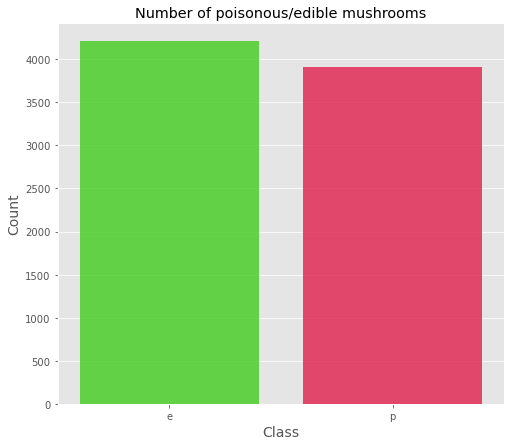

In [191]:
count = dataset['p'].value_counts()
plt.figure(figsize=(8,7))
sns.barplot(x = count.index, y = count.values, alpha=0.8, palette="prism")
plt.ylabel('Count', fontsize=14)
plt.xlabel('Class', fontsize=14)
plt.title('Number of poisonous/edible mushrooms')
plt.show()

In [192]:
dataset['p'].unique()

array(['e', 'p'], dtype=object)

In [193]:
dataset['p'].value_counts()

e    4208
p    3915
Name: p, dtype: int64

# Preprocessing

In [194]:
XY_dummies = dataset.iloc[:]
test = pd.get_dummies(XY_dummies)

In [195]:
X_dummies = dataset.iloc[:,1:23]
y_dummies = dataset.iloc[:, 0]
X = pd.get_dummies(X_dummies)
y = pd.get_dummies(y_dummies)

In [196]:
test

,p_e,p_p,x_b,x_c,x_f,x_k,x_s,x_x,s_f,s_g,...,s.3_s,s.3_v,s.3_y,u_d,u_g,u_l,u_m,u_p,u_u,u_w
0,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,1,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8119,1,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
8120,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8121,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


In [197]:
X

,x_b,x_c,x_f,x_k,x_s,x_x,s_f,s_g,s_s,s_y,...,s.3_s,s.3_v,s.3_y,u_d,u_g,u_l,u_m,u_p,u_u,u_w
0,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8118,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8119,0,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
8120,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
8121,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


In [198]:
y

,e,p
0,1,0
1,1,0
2,0,1
3,1,0
4,1,0
...,...,...
8118,1,0
8119,1,0
8120,1,0
8121,0,1


In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [200]:
print("Shape of x_train : ", X_train.shape)
print("Shape of x_test : ", X_test.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of y_test : ", y_test.shape)

Shape of x_train :  (6498, 117)
Shape of x_test :  (1625, 117)
Shape of y_train :  (6498, 2)
Shape of y_test :  (1625, 2)


In [201]:
test_size = 0.5
X_val, X_train, y_val, y_train = train_test_split(X_train, y_train, test_size = 0.5)

In [202]:
print("Shape of split x_train : ", X_train.shape)
print("Shape of split y_train : ", y_train.shape)
print("Shape of x_val : ", X_val.shape)
print("Shape of y_val : ", y_val.shape)

Shape of split x_train :  (3249, 117)
Shape of split y_train :  (3249, 2)
Shape of x_val :  (3249, 117)
Shape of y_val :  (3249, 2)


# Write train, test and validation to files

In [203]:
file = X_train.to_csv('training.txt', header=None, index=None, sep=',', mode='w')
file1 = X_test.to_csv('test.txt', header=None, index=None, sep=',', mode='w')
file2 = X_val.to_csv('val.txt', header=None, index=None, sep=',', mode='w')

In [204]:
#file4 = y_train.to_csv('training2.txt', header=None, index=None, sep=',', mode='w')
#file5 = y_test.to_csv('test2.txt', header=None, index=None, sep=',', mode='w')
#file6 = y_val.to_csv('val2.txt', header=None, index=None, sep=',', mode='w')

In [205]:
# Formulas
import math

def sig(x):
    # use logistic function as activation function
    s = 1/(1 + np.exp(-x))
    return s
    # raise Exception('Implement this part.')

def inv_sig(x):
    # derivative of the output of neruon with respect to its input
    s = sig(x)
    ds = s*(1 - s)
    return ds

    # return x*(1-x)
    # raise Exception('Implement this part.')

def err(o, t):
    # squared error function, o is the actual output value and t is the target output 
    sum_square_error = 0.0
    for i in range(len(t)):
        sum_square_error += 0.5*(o[i] - t[i])**2.0
        mean_square_error = sum_square_error / len(o)
    return mean_square_error
    # raise Exception('Implement this part.')

def inv_err(o, t):
    # derivative of squared error function with respect to o
    return (t[i] - o[i])
    # raise Exception('Implement this part.')

In [215]:
# Models
import numpy
import random
import os

LEARNING_RATE = 0.2
# LEARNING_RATE = 0.1
NUM_TRAINING_ITERATIONS = 50000
CONVERGENCE_THRESHOLD = 0.000001

#from config import LEARNING_RATE
#from formulas import sig, inv_sig, inv_err

curr_node_id = 0

class Layer:
    def __init__(self, num_nodes, input_vals, layer_num):
        self.num_nodes = num_nodes
        self.input_vals = input_vals
        self.layer_num = layer_num
        self.weight = [[random.random() for col in range(len(input_vals))] for row in range(num_nodes)]
        self.weight_delta = [[0 for col in range(len(input_vals))] for row in range(num_nodes)]
        self.layer_net = [0 for col in range(num_nodes)]
        self.layer_out = [0 for col in range(num_nodes)]
        self.bias = (random.random() * 2) - 1

    def eval(self):
        # evaluation part
        # Get input, compute the output of layer nodes.
        
        
        #l1 = Layer(self.num_nodes, self.input_vals, self.layer_num)
        #Z1 = np.dot(self.input_vals, l1.weight) + l1.bias
        #A1 = sig(Z1)
        
        #l2 = Layer(self.num_nodes, self.input_vals, self.layer_num)
        #Z2 = np.dot(A1, l2.weight) + l2.bias
        #A2 = sig(Z2)
        
        self.layer_num = sig(np.dot(self.input_vals, self.weight))
        self.layer_out = sig(np.dot(self.layer_num, self.weight))
        
        
        #result = sig(np.dot(self.input_vals, self.weight) + self.bias)
        #return result
        #raise Exception('Implement this part.')
            

    def backprop(self, other):
        # use backpropagation method to update weights
        
        weight_delta = inv_error * inv_sig        
        weight = self.weight - self.weight_delta * LEARNING_RATE
        bias += LEARNING_RATE * weight_delta    #?
        
        self.weight += LEARNING_RATE * weight
        self.weight_delta += LEARNING_RATE * weight_delta
        
        return weights, bias        
        # raise Exception('Implement this part.')

class cfile():
    def __init__(self, name, mode = 'r'):
        self = file.__init__(self, name, mode)

    def w(self, string):
        self.writelines(str(string) + '\n')
        return None

In [214]:
# Project test
#from config import NUM_TRAINING_ITERATIONS, CONVERGENCE_THRESHOLD
#from formulas import err
#from models import Layer, cfile

f = None
curr_point = 0
target = []
attrs = []
total_runs = 0
data = None
num_incorrect = 0
prev_sample_err = 0
curr_sample_err = 0

def parse_data(fname):
    # reset all the data
    global curr_point
    global total_runs
    global target
    global attrs
    global num_incorrect
    global prev_sample_err
    global curr_sample_err
    global data
    global f

    curr_point = 0
    total_runs = 0
    target = []
    attrs = []
    num_incorrect = 0
    prev_sample_err = 0
    curr_sample_err = 0

    # set the proper data file
    data_file = 'err.txt'
    if fname == 'training.txt':
        data_file = 'training_err.txt'
    elif fname == 'val.txt':
        data_file = 'val_err.txt'
    elif fname == 'testing.txt':
        data_file = 'testing_err.txt'


    # clear the file
    open(data_file, 'w+').close()

    # open the data file for logging
    data = cfile(data_file, 'w')

    f = open(fname, 'r').readlines()

    for row in f:
        row = [x.strip() for x in row.split(',')]
        row = [int(num) for num in row]    
        target.append(int(row[1])) #row[0] represent p class, row[1] represent e class.
                                   #if you represent e and p classes into one elment (0 for p and 1 for e, etc.), please modifiy.
        attrs.append(row[2:])

if __name__ == '__main__':
    print ("Parsing the training dataset...")
    # parse the training dataset and store its information into globals
    parse_data('training.txt')

    # set up the layers to be used    
    x = Layer(6, attrs[curr_point], 1)
    y = Layer(3, x.layer_out, 2)

    print ("Begining training the neural network:")
    # iterate through to train the neural network
    while total_runs < NUM_TRAINING_ITERATIONS:        

        # set up the first layer and evaluate it
        l1 = x.eval()
        # raise Exception('Implement this part.')

        # set up the second layer and evaluate it
        l2 = x.eval()
        # raise Exception('Implement this part.')

        # backpropogate
        y.backprop(target[curr_point])        
        x.backprop(y)
        l2.backprop(y)
        l1.backprop(y)

        # get the current error
        # raise Exception('Implement this part.')
        curr_err = err(x, y)                        #<--------------err(l2,l1)?
        #call err function to calculate

        # round up and down to check err
        if y.layer_out[0] >= 0.5:
            temp = 1
        else:
            temp = 0

        # increment the number incorrect if its wrong
        if(temp != target[curr_point]):
            num_incorrect += 1

        # check to see if we have converged
        if total_runs % 100 == 0:
            prev_sample_err = curr_sample_err
            curr_sample_err = curr_err
            if abs(prev_sample_err - curr_sample_err) < CONVERGENCE_THRESHOLD:
                print ("Data has converged at the " + str(total_runs) + "th run.")
                break;

        # print information about the current iteration
        print ("Current iteration: " + str(total_runs))
        print ("Current error: " + str(curr_err) + "\n")
        data.w(curr_err)

        # iterate
        total_runs += 1
        curr_point += 1

        if curr_point >= len(f):
            curr_point = 0

    # close the file
    data.close()



    print ("Neural network is done training! Hit enter to validation processing.")
    print ("Error percentage on training set: " + str(float(num_incorrect)/NUM_TRAINING_ITERATIONS))
    raw_input()


    print ("Parsing the validation dataset...")
    # parse the validation dataset and store its information into globals
    parse_data('val.txt')

    

    print ("Begining validating the neural network:")
    # iterate through to train the neural network
    while total_runs < len(f):        

        # set up the first layer and evaluate it
        l1 = x.eval()
        # raise Exception('Implement this part.')

        # set up the second layer and evaluate it
        l2 = x.eval()
        # raise Exception('Implement this part.')

        # get the current error
        # raise Exception('Implement this part.')    
        curr_err = err(x, y)
        #call err function to calculate


        # round up and down to check err
        if y.layer_out[0] >= 0.5:
            temp = 1
        else:
            temp = 0

        # increment the number incorrect if its wrong
        if(temp != target[curr_point]):
            num_incorrect += 1

        # check to see if we have converged
        if total_runs % 100 == 0:
            prev_sample_err = curr_sample_err
            curr_sample_err = curr_err
            if abs(prev_sample_err - curr_sample_err) < CONVERGENCE_THRESHOLD:
                print ("Data has converged at the " + str(total_runs) + "th run.")
                break;

        # print information about the current iteration
        print ("Current iteration: " + str(total_runs))
        print ("Current error: " + str(curr_err) + "\n")
        data.w(curr_err)

        # iterate
        total_runs += 1
        curr_point += 1

        if curr_point >= len(f):
            curr_point = 0

    # close the file
    data.close()



    print ("Neural network is done validating! Hit enter to test it.")
    print ("Error percentage on validation set: " + str(float(num_incorrect)/NUM_TRAINING_ITERATIONS))
    raw_input()

    print ("Begin testing the neural network:")
    # parse the testing data and store its information into globals
    parse_data('testing.txt')

    # iterate through to test the neural network
    while curr_point < len(f):
        
        # set up the first layer and evaluate it
        l1 = x.eval()
        # raise Exception('Implement this part.')

        # set up the second layer and evaluate it
        l2 = x.eval()
        # raise Exception('Implement this part.')

        # get the current error
        # raise Exception('Implement this part.')
        curr_err = err(x, y)
        #call err function to calculate\
        

        # round up and down to check err
        if y.layer_out[0] >= 0.5:
            temp = 1
        else:
            temp = 0

        # increment the number incorrect if its wrong
        if(temp != target[curr_point]):
            num_incorrect += 1


        # print information about the current iteration
        print ("Current iteration: " + str(total_runs))
        print ("Current Error: " + str(curr_err) + "\n")
        data.w(curr_err)

        # iterate
        total_runs += 1
        curr_point += 1

    data.close()
    print ("Testing done! Check out the generated output files ('testing_err.txt' and 'training_err.txt')")
    print ("Error percentage on testing set: " + str(float(num_incorrect)/len(f)))

Parsing the training dataset...
Begining training the neural network:


ValueError: shapes (115,) and (6,115) not aligned: 115 (dim 0) != 6 (dim 0)